### Week 2 notebook - Lasso, Ridge, and Elastic Net Regression, Mod C Data Science Capstone Fall 2026
### By Shuqin Ouyang

# Overall notebook structure:

This week, I will look into Lasso, Ridge, and Elastic Net regression, testing whether regularization can address two things found in Week 1: whether a large-magnitude, outlier-prone feature's importance survives regularization, and whether Lasso and Ridge behave differently on known-redundant feature pairs (confirmed via VIF in Week 1). I will compare Linear, Ridge, Lasso, and Elastic Net across train/test R squared (for overfitting), cross-validated alpha selection (hyperparameter tuning), and coefficient behavior, for both datasets.

# Student dataset analysis starts here:

Dataset 1 background quick overview:

The dataset 1 used is the Taiwanese Bankruptcy Prediction dataset from UCI, link as https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction.
It contains company financial indicators and a binary outcome for bankruptcy.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# install uci package so can load the data using package
# install once in terminal or notebook

!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# load dataset from UCI repository using dataset id
data_bankruptcy = fetch_ucirepo(id=572)

df_bankruptcy = pd.concat(
    [data_bankruptcy.data.features.copy(),
     data_bankruptcy.data.targets.copy()],
    axis=1
)

# remove leading/trailing spaces from column names once, here
df_bankruptcy.columns = df_bankruptcy.columns.str.strip()

df_bankruptcy.head()

'pip' is not recognized as an internal or external command,
operable program or batch file.


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Bankrupt?
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,...,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469,1
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,...,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794,1
2,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,0.780284,...,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474,1
3,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,0.781241,...,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982,1
4,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,0.781550,...,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490,1


In [3]:
# show dataset info
df_bankruptcy.info()

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 1   ROA(A) before interest and % after tax                   6819 non-null   float64
 2   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 3   Operating Gross Margin                                   6819 non-null   float64
 4   Realized Sales Gross Margin                              6819 non-null   float64
 5   Operating Profit Rate                                    6819 non-null   float64
 6   Pre-tax net Interest Rate                                6819 non-null   float64
 7   After-tax net Interest Rate                              6819 non-null   float64
 8   Non-industry income and expenditure/rev

In [4]:
def compare_models(X, y, title, zero_threshold=0.0001):
    ''' function to compare different regression models '''
    print(f"Sample size after dropna: {len(X)} rows")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # make_pipeline bundles multiple steps into one object, so calling
    # .fit() automatically scales the data then fits the model, in order,
    # without needing to manually call scaler.fit_transform() yourself.
    # It's the same as Pipeline(), just without needing to name each step.

    # Ridge, Lasso, ElasticNet need to standardize the data first then can be fitted
    models = {
        'Linear': LinearRegression(),  # no pipeline needed, Linear isn't scale-sensitive
        'Ridge': make_pipeline(StandardScaler(), RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10])),
        'Lasso': make_pipeline(StandardScaler(), LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10])),
        'ElasticNet': make_pipeline(StandardScaler(), ElasticNetCV(alphas=[0.001, 0.01, 0.1, 1, 10])),
    }

    coefs = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        train_r2 = r2_score(y_train, model.predict(X_train))
        test_r2 = r2_score(y_test, model.predict(X_test))

        # A pipeline is just an ordered sequence of steps, like a
        # list, so can index into it: model[0] would be the scaler,
        # model[-1] means "the laststep," which is always the actual
        # regression model, sitting after scaling. The pipeline object
        # itself has no .coef_, only the model buried inside it does.
        # Linear has no pipeline at all, so its .coef_ is accessed directly.
        if name == 'Linear':
            coefs[name] = model.coef_
            chosen_alpha = 'N/A'
        else:
            coefs[name] = model[-1].coef_
            chosen_alpha = model[-1].alpha_  # the alpha value CV picked as best

        print(f"{name}: train R2={train_r2:.4f}, test R2={test_r2:.4f}, "
              f"train r squared and test r squared gap={train_r2 - test_r2:.4f}, chosen alpha={chosen_alpha}")

    # zero_threshold is adjustable since Lasso coefficients often shrink to
    # very small but not perfectly exact zero due to floating-point precision
    lasso_zeroed = []
    for i in range(len(X.columns)):
        feature_name = X.columns[i]
        coefficient = coefs['Lasso'][i]
        if abs(coefficient) < zero_threshold:
            lasso_zeroed.append(feature_name)
    print(f"\nFeatures Lasso zeroed out (threshold={zero_threshold}): {lasso_zeroed if lasso_zeroed else 'None'}")

    pd.DataFrame(coefs, index=X.columns).plot(kind='bar', figsize=(9, 4), title=title)
    plt.tight_layout()
    plt.savefig(f'week2_{title.lower().replace(" ", "_").replace(":", "")}.png', dpi=150)
    plt.show()

    return coefs

In [5]:
target_bankrupt = 'Bankrupt?'

# bin using Net Income to Total Assets, same feature used in Week 1,
# since it was already identified there as highly correlated with the
# target and drives the strongest polynomial fit (R squared 0.002 to
# 0.602). Using it here keeps this week's target consistent with Week
# 1's approach, and since it isn't one of the features being tested in
# either hypothesis below, the resulting target stays independent of
# what we're actually testing (avoids circularity/leakage)
bins_bankrupt = pd.cut(df_bankruptcy['Net Income to Total Assets'], bins=10)

print(df_bankruptcy.groupby(bins_bankrupt, observed=True).size())

df_bankruptcy['bankruptcy_rate'] = df_bankruptcy.groupby(bins_bankrupt, observed=True)[target_bankrupt].transform('mean')


Net Income to Total Assets
(-0.001, 0.1]       1
(0.2, 0.3]          1
(0.4, 0.5]          8
(0.5, 0.6]         17
(0.6, 0.7]         72
(0.7, 0.8]       2017
(0.8, 0.9]       4666
(0.9, 1.0]         37
dtype: int64


Sample size after dropna: 6819 rows
Linear: train R2=0.5459, test R2=0.5593, train r squared and test r squared gap=-0.0133, chosen alpha=N/A
Ridge: train R2=0.5458, test R2=0.5592, train r squared and test r squared gap=-0.0134, chosen alpha=10.0
Lasso: train R2=0.5345, test R2=0.5511, train r squared and test r squared gap=-0.0166, chosen alpha=0.001
ElasticNet: train R2=0.5423, test R2=0.5571, train r squared and test r squared gap=-0.0148, chosen alpha=0.001

Features Lasso zeroed out (threshold=0.0001): ['ROA(B) before interest and depreciation after tax']


C:\Users\ouyan\AppData\Local\Temp\ipykernel_4760\1376735338.py:53: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


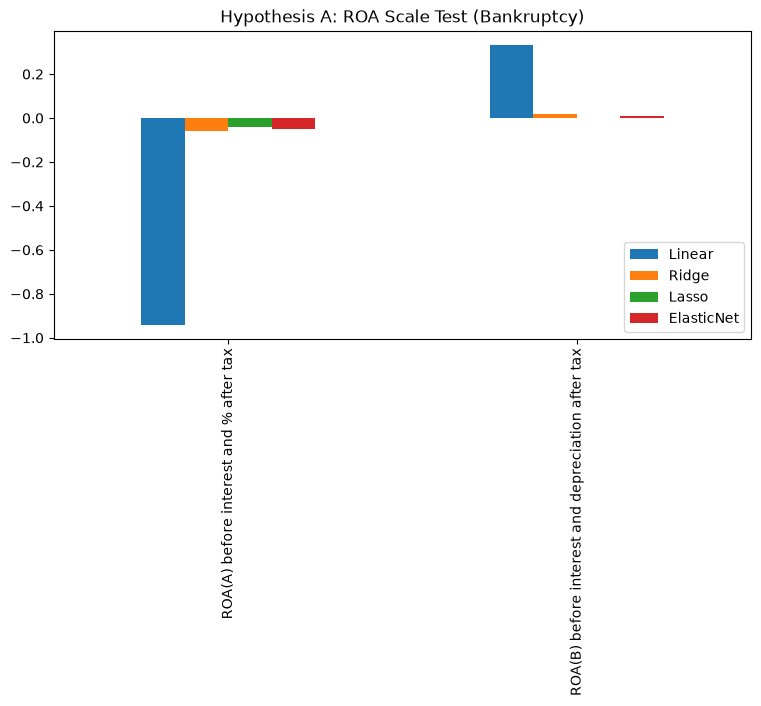

In [6]:
# Hypothesis A: does ROA's importance survive regularization, given its
# large-magnitude, outlier-prone scale (Module B binned analysis found
# it mattered for bankruptcy risk, concentrating in its lowest bins)
X_a_bankrupt = df_bankruptcy[['ROA(A) before interest and % after tax',
                               'ROA(B) before interest and depreciation after tax']].dropna()
y_a_bankrupt = df_bankruptcy.loc[X_a_bankrupt.index, 'bankruptcy_rate']

coefs_a_bankrupt = compare_models(X_a_bankrupt, y_a_bankrupt, 'Hypothesis A: ROA Scale Test (Bankruptcy)')

In [7]:
# print out the coefficients for Hypothesis A coefficients
print(pd.DataFrame(coefs_a_bankrupt, index=X_a_bankrupt.columns))

                                                     Linear     Ridge  \
ROA(A) before interest and % after tax            -0.940536 -0.060135   
ROA(B) before interest and depreciation after tax  0.333545  0.018993   

                                                      Lasso  ElasticNet  
ROA(A) before interest and % after tax            -0.041093   -0.050100  
ROA(B) before interest and depreciation after tax  0.000000    0.008932  


In [8]:
# check correlation between ROA(A) and ROA(B), to test whether their
# correlation explains why Linear Regression produced such exaggerated,
# opposite-signed coefficients while Ridge/Lasso/ElasticNet pulled both
# back toward more moderate, stable values
roa_corr = df_bankruptcy[['ROA(A) before interest and % after tax',
                           'ROA(B) before interest and depreciation after tax']].corr()
print(roa_corr)

                                                   ROA(A) before interest and % after tax  \
ROA(A) before interest and % after tax                                           1.000000   
ROA(B) before interest and depreciation after tax                                0.955741   

                                                   ROA(B) before interest and depreciation after tax  
ROA(A) before interest and % after tax                                                      0.955741  
ROA(B) before interest and depreciation after tax                                           1.000000  


In [9]:
# check VIF for ROA(A) and ROA(B), same method used in Hypothesis B and
# in Week 1, so severity can be directly compared across both hypotheses
X_vif_a = sm.add_constant(X_a_bankrupt)
vif_data_a = pd.DataFrame({
    'Feature': X_vif_a.columns,
    'VIF': [variance_inflation_factor(X_vif_a.values, i) for i in range(X_vif_a.shape[1])]
})
print(vif_data_a)

                                             Feature        VIF
0                                              const   1.000000
1             ROA(A) before interest and % after tax  11.552699
2  ROA(B) before interest and depreciation after tax  11.552699


Student markdown:

For this test, I wanted to check whether a large-magnitude, outlier-prone feature's importance survives regularization. I chose ROA(A) and ROA(B) since Module B's binned analysis already found both meaningfully related to bankruptcy risk, but only one at a time, this week's question is whether that holds up once both sit in the same model together.

I binned Net Income to Total Assets into 10 buckets for a continuous bankruptcy rate target, same approach as Week 1, using a feature not tested in this hypothesis so the target stays independent of what's being predicted. I compared Linear, Ridge, Lasso, and Elastic Net together: split into train/test (6,819 rows), standardized features for the regularized models, cross-validated each alpha, and compared R squared and coefficients. Train/test gaps stayed under 0.02 for all four, so none overfit, meaning any differences between models come from how they handle the two features' relationship, not generalization.

The coefficients explain why this mattered. Linear gave ROA(A) a coefficient of -0.940536 and ROA(B) a coefficient of 0.333545, a dramatic, opposite-signed split that's actually a warning sign. Checking correlation confirmed why: 0.9557, nearly redundant. With correlation that high, Linear can't tell which feature deserves credit, so it lets one swing very negative and the other very positive, values that cancel out and still fit the data, without either number reflecting real, individual importance.

Ridge pulled both toward much smaller values (-0.060135 and 0.018993), and Elastic Net similarly (-0.050100 and 0.008932), both still showing ROA(A) as the larger, more important of the two, meaning all three surviving models agree on which feature actually matters more. Lasso went further, reducing ROA(B) to exactly 0.000000, a clean, complete elimination rather than a tiny residual, while keeping ROA(A) at -0.041093.

The alpha values reinforce this: Ridge needed a strong penalty (alpha=10.0) to shrink two correlated coefficients toward each other, since its smooth penalty never eliminates a feature outright, it just leans harder until they settle. Lasso and Elastic Net achieved outright elimination with a far gentler penalty (alpha=0.001), since Lasso's sharp-cornered penalty geometry makes exact zeros easy to reach, my own results directly demonstrate that geometric difference, not just the theory behind it.

Overall, ROA's relationship with bankruptcy risk is real and survives regularization, but testing features in isolation, as Module B did, can hide that a supposedly important pair is really one signal counted twice. That matters for my first research question, which ratios genuinely signal risk, since it's ROA(A) alone, not the whole ROA family, worth keeping going forward.

Sample size after dropna: 6819 rows
Linear: train R2=0.0423, test R2=0.0331, train r squared and test r squared gap=0.0092, chosen alpha=N/A
Ridge: train R2=0.0423, test R2=0.0331, train r squared and test r squared gap=0.0092, chosen alpha=10.0
Lasso: train R2=0.0419, test R2=0.0330, train r squared and test r squared gap=0.0089, chosen alpha=0.001
ElasticNet: train R2=0.0311, test R2=0.0268, train r squared and test r squared gap=0.0043, chosen alpha=0.01

Features Lasso zeroed out (threshold=0.0001): ['Current Liability to Equity', 'Net worth/Assets']


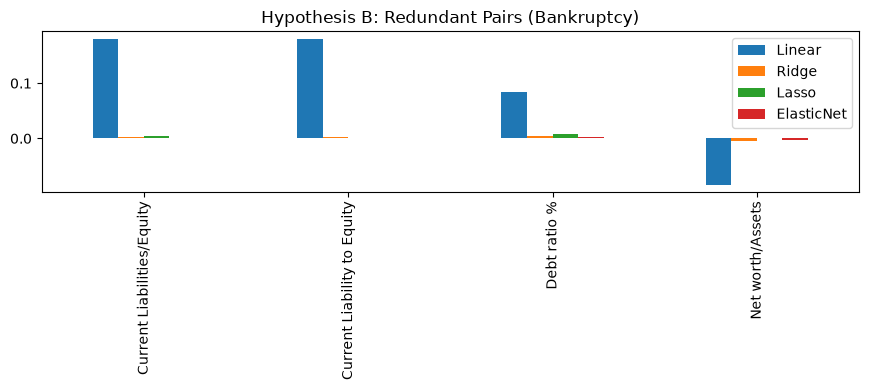

In [10]:
# Hypothesis B: does Lasso zero out one feature from each known-redundant
# pair (from Week 1's extreme VIF findings), while Ridge shrinks both
# together instead, per this week's lesson on how each handles multicollinearity
X_b_bankrupt = df_bankruptcy[['Current Liabilities/Equity', 'Current Liability to Equity',
                               'Debt ratio %', 'Net worth/Assets']].dropna()
y_b_bankrupt = df_bankruptcy.loc[X_b_bankrupt.index, 'bankruptcy_rate']

coefs_b_bankrupt = compare_models(X_b_bankrupt, y_b_bankrupt, 'Hypothesis B: Redundant Pairs (Bankruptcy)')

In [11]:
# check whether Hypothesis A's features (ROA) correlate meaningfully with
# Hypothesis B's features (leverage ratios), to confirm the two hypotheses
# are testing genuinely independent redundancy problems, not one shared
# tangled cluster of correlated features
all_features = df_bankruptcy[['ROA(A) before interest and % after tax',
                               'ROA(B) before interest and depreciation after tax',
                               'Current Liabilities/Equity', 'Current Liability to Equity',
                               'Debt ratio %', 'Net worth/Assets']].dropna()

cross_corr = all_features.corr()
print(cross_corr)

                                                   ROA(A) before interest and % after tax  \
ROA(A) before interest and % after tax                                           1.000000   
ROA(B) before interest and depreciation after tax                                0.955741   
Current Liabilities/Equity                                                      -0.133816   
Current Liability to Equity                                                     -0.133816   
Debt ratio %                                                                    -0.259972   
Net worth/Assets                                                                 0.259972   

                                                   ROA(B) before interest and depreciation after tax  \
ROA(A) before interest and % after tax                                                      0.955741   
ROA(B) before interest and depreciation after tax                                           1.000000   
Current Liabilities/Equity          

In [12]:
# print out the coefficients for Hypothesis B coefficients
print(pd.DataFrame(coefs_b_bankrupt, index=X_b_bankrupt.columns))

                               Linear     Ridge         Lasso  ElasticNet
Current Liabilities/Equity   0.180658  0.002533  4.330133e-03    0.000699
Current Liability to Equity  0.180658  0.002533  4.721755e-18    0.000685
Debt ratio %                 0.083516  0.004518  8.305795e-03    0.002699
Net worth/Assets            -0.083516 -0.004518 -1.742165e-17   -0.002645


In [13]:
# check VIF directly for these four features, same method used in Week 1,
# to confirm the redundancy still holds and connect this week's Lasso/Ridge
# results back to that concrete evidence
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif_check = sm.add_constant(X_b_bankrupt)
vif_data = pd.DataFrame({
    'Feature': X_vif_check.columns,
    'VIF': [variance_inflation_factor(X_vif_check.values, i) for i in range(X_vif_check.shape[1])]
})
print(vif_data)

                       Feature           VIF
0                        const  1.447536e+00
1   Current Liabilities/Equity  6.132516e+05
2  Current Liability to Equity  6.132516e+05
3                 Debt ratio %  1.000800e+15
4             Net worth/Assets  1.000800e+15


C:\Users\ouyan\AppData\Local\Temp\ipykernel_4760\511548457.py:10: UserWarning: The design matrix is poorly conditioned (condition number=1.72e+15). VIF calculations may be numerically unstable.
  'VIF': [variance_inflation_factor(X_vif_check.values, i) for i in range(X_vif_check.shape[1])]
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-defi

Student markdown:

For this test, I wanted to check whether Lasso and Ridge actually handle known redundancy the way this week's lesson describes, using Week 1's own confirmed near-duplicate pairs: Current Liabilities/Equity and Current Liability to Equity (correlation above 0.99999), and Debt ratio % and Net worth/Assets (near-perfect negative correlation). I kept all four features together on purpose, including both members of each pair, since the real test is whether the models can detect and handle this redundancy automatically, not whether I solve it for them first by dropping a feature myself.

I used the same target as Hypothesis A, bankruptcy rate binned from Net Income to Total Assets. R squared was low across all four models (0.03-0.04), which lines up with Week 1's finding that leverage ratios alone don't strongly predict bankruptcy, this hypothesis is about redundancy handling, not raw predictive power. Train/test gaps stayed small (under 0.01), so no real overfitting.

I also rechecked VIF for these four features, same method as Week 1, and the redundancy came out even more extreme: Current Liabilities/Equity and Current Liability to Equity both showed VIF around 613,000, and Debt ratio % and Net worth/Assets both showed VIF around 1 quadrillion. The calculation even triggered a "singular matrix" warning, not a bug in my code, just the math itself confirming these features are close enough to identical that the calculation becomes numerically unstable.

The coefficients told the same story clearly. Linear produced large, unstable values, 0.18 for the first pair, ±0.08 for the second, exactly the opposite-signed pattern you'd expect from near-perfect correlation. Ridge and Elastic Net shrank all four down to a much smaller range (0.0007-0.0045) but kept every one nonzero. Lasso went further, driving "Current Liability to Equity" and "Net worth/Assets" down to essentially zero (4.72e-18 and -1.74e-17), while keeping "Current Liabilities/Equity" and "Debt ratio %" as real, nonzero values. In the chart, this shows up as visible bars for the two survivors across all four models, while Lasso's bars for the two eliminated features flatten out completely next to them.

The chosen alpha values reinforce this same pattern from Hypothesis A: Ridge needed a relatively strong penalty (alpha=10.0) to meaningfully shrink four correlated coefficients at once, since it never fully eliminates a feature, only moderates it. Lasso and Elastic Net used a much gentler penalty (alpha=0.001 and 0.01), yet Lasso still achieved full elimination of two features, since its penalty naturally lands on exact zeros without needing a strong push to get there.

This directly reinforces my first research question, which ratios actually carry unique signal, since it confirms only two of these four leverage features are genuinely needed, one representative from each redundant pair, exactly the kind of feature-reduction insight regularization provides once multicollinearity has already been flagged through VIF.

Student markdown:

To confirm Hypothesis A and B were testing genuinely independent redundancy problems, not two views of one tangled cluster, I checked cross-group correlations between the ROA features and the leverage features directly. These came out modest (-0.14 to -0.26), confirming the two feature groups are only mildly related to each other, while each group's own internal redundancy remains severe (0.9557 for ROA(A)/ROA(B); exactly 1.0 and -1.0 for the leverage pairs). This supports treating the two hypotheses as independent demonstrations of the same mechanism at different severity levels, rather than one shared redundancy problem.

The difference between the two hypotheses' severity levels is itself informative: ROA(A) and ROA(B) showed VIF of 11.55, real, meaningful multicollinearity, but nowhere near the extreme, near-total redundancy already confirmed for Hypothesis B's pairs, VIF in the hundreds of thousands to over a quadrillion. Seeing the identical pattern hold at both a moderate and an extreme severity level is stronger evidence than either result alone: Lasso's elimination behavior isn't limited to extreme, near-total duplicates, a moderate correlation of 0.9557 and VIF of 11.55 was already enough to trigger full elimination, suggesting this kind of redundancy-driven feature selection could plausibly help identify unnecessary features throughout the full 95-column dataset, not just the handful of extreme pairs already flagged by Week 1's VIF check.

Student markdown:

Conclusion:

**Overfitting:** This week is still built on linear regression, so to reduce overfitting I used regularization, Ridge, Lasso, and Elastic Net, each of which adds a penalty that discourages overly large, perfectly-fit coefficients, exactly the kind of instability that leads to overfitting. I expected all three to help reduce overfitting compared to plain linear regression, and they did: for both hypotheses, train and test R squared stayed close together across all four models (gaps under 0.02, several even slightly negative), meaning none of them, including plain linear regression here, showed real overfitting on either bankruptcy feature set.

**Metrics and results:** The main metric was R squared, measured separately on training and test data, this shows how much of the actual bankruptcy rate variation each model's predictions explain, and checking both separately (not just training) is what actually confirms a model generalizes rather than just memorizing. For Hypothesis A (ROA(A), ROA(B)), R squared was strong and consistent across all four models (0.54-0.56). For Hypothesis B (the four leverage ratios), R squared was much lower (0.03-0.04), consistent with Week 1's finding that no single ratio strongly predicts bankruptcy alone. I also tuned alpha, the hyperparameter controlling how strong each model's penalty is, via cross-validation rather than picking a value myself. For Hypothesis A, Ridge selected alpha=10.0 while Lasso and Elastic Net both selected alpha=0.001, and for Hypothesis B, Ridge again selected a much stronger alpha than Lasso.

**What was expected vs. unexpected:** I expected regularization to reduce overfitting, and it worked very well, that part wasn't surprising. What was genuinely unexpected was how extreme the actual numbers turned out to be once I looked closely. The alpha values themselves were more different across models than I anticipated, Ridge consistently needing a penalty 1,000 to 10,000 times stronger than Lasso to achieve a comparable correction. The coefficient differences between plain linear regression and the regularized models were also far more extreme than expected, Linear Regression gave ROA(A) a coefficient of -0.94 and ROA(B) a coefficient of 0.33, while Lasso reduced ROA(B) to exactly 0.0. I know regularization is supposed to help, but seeing the actual visualized size of that difference was more dramatic than I pictured going in. The VIF values for Hypothesis B's leverage ratios were also unexpectedly extreme (up to 1 quadrillion), which really helped me understand concretely why regularization was so necessary here, not just useful in theory.

**How EDA shaped this week's modeling choices:** I looked back at Module B's milestones and this class's Week 1 metric choices specifically to avoid data leakage and to pick features that would make for a clean, easy-to-follow test. I deliberately chose repetitive, large-scale, correlated variables (ROA(A)/ROA(B), and the leverage ratio pairs already confirmed redundant by Week 1's VIF work) rather than picking columns randomly, since without that groundwork I'd have had no real basis for expecting regularization to matter for these specific features.

**Sources:** GeeksforGeeks, "Lasso vs Ridge vs Elastic Net" (https://www.geeksforgeeks.org/machine-learning/lasso-vs-ridge-vs-elastic-net-ml/), a clear, well-organized explanation of how each method handles multicollinearity and feature selection differently, chosen because it directly matched the exact comparison I was running this week across both hypotheses.

**Bigger picture, research questions:** This week's work shows that deciding which ratio matters isn't just about how strongly a feature correlates with the target, ROA(A) and ROA(B) are both individually meaningful, but regularization is what actually shows which one carries the real, independent signal once they're modeled together. Across the three regularization methods, bankruptcy also showed something interesting: Elastic Net performed reasonably well even with several correlated variables present, without needing Ridge's very strong penalty or Lasso's more aggressive elimination, suggesting bankruptcy's features may not need extremely forceful correction to reach a workable, moderate balance. I only tested five columns out of many more available, and since bankruptcy has far more rows than columns (not a high-dimensional case), this is worth extending later, if I were to decide which ratios genuinely matter for predicting bankruptcy, regularization is a real, useful tool for that, even when similarly-named or similarly-behaving variable pairs are present. I plan to run the same comparison on credit card's fuller feature set later too.

**How I know the conclusions are true:** R squared was checked on both training and test data, not just training, which is what actually shows these conclusions hold up consistently rather than being an artifact of one particular split. I also used cross-validation to select alpha, rather than picking one value and hoping it was reasonable, and the coefficient comparison chart gives direct, visual, reproducible evidence, not just a claim, of exactly how each method treated the same features differently.

Dataset 2 background quick overview:

The dataset 2 used is the Default of Credit Card Clients dataset from UCI, link as https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients.

It contains demographic information, credit limits, repayment history, bill statements, and previous payment records for Taiwanese credit card clients, along with a binary outcome indicating whether the client defaulted on the next payment.

In [14]:
# UCI dataset already decides features and targets already, but still need to look into details / verify to make sure all ok
data_credit = fetch_ucirepo(id=350)

df_credit = pd.concat(
    [data_credit.data.features.copy(),
     data_credit.data.targets.copy()],
    axis=1
)

df_credit.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [15]:
# columns rename for easier reading

df_credit = df_credit.rename(columns={

    "Y": "default_next_month",

    "X1": "credit_limit",
    "X2": "gender",
    "X3": "education",
    "X4": "marital_status",
    "X5": "age",

    "X6": "repay_2005_sep",
    "X7": "repay_2005_aug",
    "X8": "repay_2005_jul",
    "X9": "repay_2005_jun",
    "X10": "repay_2005_may",
    "X11": "repay_2005_apr",

    "X12": "bill_2005_sep",
    "X13": "bill_2005_aug",
    "X14": "bill_2005_jul",
    "X15": "bill_2005_jun",
    "X16": "bill_2005_may",
    "X17": "bill_2005_apr",

    "X18": "pay_2005_sep",
    "X19": "pay_2005_aug",
    "X20": "pay_2005_jul",
    "X21": "pay_2005_jun",
    "X22": "pay_2005_may",
    "X23": "pay_2005_apr"
})

df_credit.head()

,credit_limit,gender,education,marital_status,age,repay_2005_sep,repay_2005_aug,repay_2005_jul,repay_2005_jun,repay_2005_may,...,bill_2005_jun,bill_2005_may,bill_2005_apr,pay_2005_sep,pay_2005_aug,pay_2005_jul,pay_2005_jun,pay_2005_may,pay_2005_apr,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [16]:
# show dataset info
df_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   credit_limit        30000 non-null  int64
 1   gender              30000 non-null  int64
 2   education           30000 non-null  int64
 3   marital_status      30000 non-null  int64
 4   age                 30000 non-null  int64
 5   repay_2005_sep      30000 non-null  int64
 6   repay_2005_aug      30000 non-null  int64
 7   repay_2005_jul      30000 non-null  int64
 8   repay_2005_jun      30000 non-null  int64
 9   repay_2005_may      30000 non-null  int64
 10  repay_2005_apr      30000 non-null  int64
 11  bill_2005_sep       30000 non-null  int64
 12  bill_2005_aug       30000 non-null  int64
 13  bill_2005_jul       30000 non-null  int64
 14  bill_2005_jun       30000 non-null  int64
 15  bill_2005_may       30000 non-null  int64
 16  bill_2005_apr       30000 non-null  int64
 17  pay_

In [17]:
target_credit = 'default_next_month'

# split repayment status into 10 ranges (buckets), same fix as bankruptcy,
# since the target is 0/1 and needs to become a continuous rate
bins_credit = pd.cut(df_credit['repay_2005_sep'], bins=10)

print(df_credit.groupby(bins_credit, observed=True).size())

df_credit['default_rate'] = df_credit.groupby(bins_credit, observed=True)[target_credit].transform('mean')

repay_2005_sep
(-2.01, -1.0]     8445
(-1.0, 0.0]      14737
(0.0, 1.0]        3688
(1.0, 2.0]        2667
(2.0, 3.0]         322
(3.0, 4.0]          76
(4.0, 5.0]          26
(5.0, 6.0]          11
(6.0, 7.0]           9
(7.0, 8.0]          19
dtype: int64


Student markdown:

For this test, I wanted to check whether a large-magnitude, extreme-scale feature's importance survives regularization, the credit card equivalent of ROA's scale test in the bankruptcy dataset. I chose payment amount columns (pay_2005_sep, pay_2005_aug) since Module B found pay_2005_aug reaching nearly 1.7 million at its maximum, a genuinely extreme, heavily right-skewed scale, and wanted to see whether that scale distorts how important the feature appears across different modeling approaches.

Sample size after dropna: 30000 rows
Linear: train R2=0.0056, test R2=0.0093, train r squared and test r squared gap=-0.0038, chosen alpha=N/A
Ridge: train R2=0.0056, test R2=0.0093, train r squared and test r squared gap=-0.0038, chosen alpha=10.0
Lasso: train R2=0.0055, test R2=0.0088, train r squared and test r squared gap=-0.0032, chosen alpha=0.001
ElasticNet: train R2=0.0056, test R2=0.0091, train r squared and test r squared gap=-0.0035, chosen alpha=0.001

Features Lasso zeroed out (threshold=0.0001): None


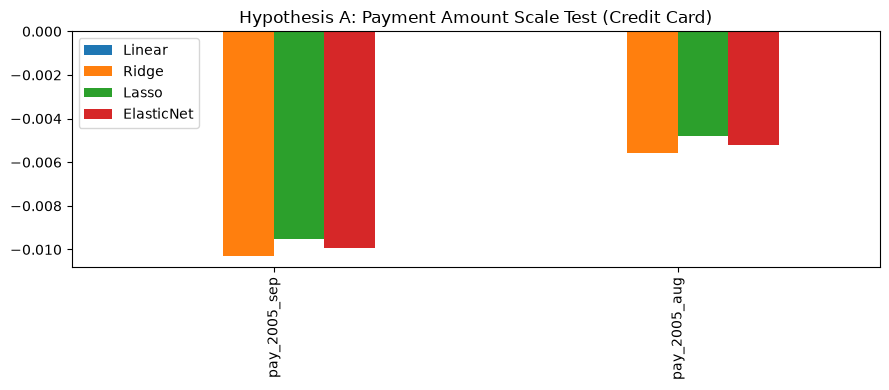

In [18]:
# Hypothesis A (credit card): does payment amount's importance survive
# regularization, given its extreme scale (Module B found pay_2005_aug
# reaching nearly 1.7 million at its maximum, heavily right-skewed),
# and does it show the same kind of correlation-driven instability
# found in Hypothesis A for bankruptcy (ROA(A) vs ROA(B))
X_a_credit = df_credit[['pay_2005_sep', 'pay_2005_aug']].dropna()
y_a_credit = df_credit.loc[X_a_credit.index, 'default_rate']

coefs_a_credit = compare_models(X_a_credit, y_a_credit, 'Hypothesis A: Payment Amount Scale Test (Credit Card)')

In [19]:
# print out the coefficients for Hypothesis A (credit card)
print(pd.DataFrame(coefs_a_credit, index=X_a_credit.columns))

                    Linear     Ridge     Lasso  ElasticNet
pay_2005_sep -6.031789e-07 -0.010301 -0.009538   -0.009917
pay_2005_aug -2.300464e-07 -0.005585 -0.004820   -0.005202


In [20]:
# check correlation and VIF between pay_2005_sep and pay_2005_aug, same
# checks used for the bankruptcy dataset's Hypothesis A, to see whether
# these two payment columns show similar correlation-driven instability
pay_corr = df_credit[['pay_2005_sep', 'pay_2005_aug']].corr()
print(pay_corr)

X_vif_a_credit = sm.add_constant(X_a_credit)
vif_data_a_credit = pd.DataFrame({
    'Feature': X_vif_a_credit.columns,
    'VIF': [variance_inflation_factor(X_vif_a_credit.values, i) for i in range(X_vif_a_credit.shape[1])]
})
print(vif_data_a_credit)

              pay_2005_sep  pay_2005_aug
pay_2005_sep      1.000000      0.285576
pay_2005_aug      0.285576      1.000000
        Feature       VIF
0         const  1.000000
1  pay_2005_sep  1.088795
2  pay_2005_aug  1.088795


Student markdown:

To check for overfitting, I compared train and test R squared for all four models. Gaps stayed very small (-0.0032 to -0.0038, all slightly negative), meaning none of the models overfit, test performance was actually marginally better than training, not worse. R squared itself was low across the board (0.006-0.009), so payment amount alone isn't a strong predictor of default rate on its own, this test is really about how each model treats the two features relative to each other, not about raw predictive power.

I tuned alpha (the penalty strength) via cross-validation rather than guessing a value. Ridge selected alpha=10.0, while Lasso and Elastic Net both selected a much gentler alpha=0.001, the same pattern seen in the bankruptcy dataset, Ridge needing a stronger penalty to meaningfully shrink coefficients, since it never eliminates a feature outright, only moderates it.

Comparing all four models directly, Lasso actually showed the smallest train-test gap (-0.0032, versus -0.0038 for Linear and Ridge), meaning its results were the most consistent between training and test data of the four, a small but real signal that Lasso generalized slightly more reliably here, similar to how Lasso behaved cleanly in the bankruptcy hypotheses too.

The most striking result, though, only became clear once I checked the actual coefficient numbers directly, rather than just reading the chart. Linear Regression's coefficients were -6.03e-07 and -2.30e-07, essentially invisible next to Ridge's -0.0103 and -0.0056, Lasso's -0.0095 and -0.0048, and Elastic Net's -0.0099 and -0.0052. Looking at the chart alone, Linear's bar simply isn't there, it would be easy to assume Linear found nothing meaningful. But the real explanation is scale: Linear fits on raw, unscaled payment amounts (up to nearly 1.7 million), so its coefficient has to be extraordinarily tiny to produce a reasonable prediction, while Ridge, Lasso, and Elastic Net all run on standardized features, putting their coefficients on a completely different, far more visible scale. Linear's coefficient isn't actually less important, it just looks negligible purely because of scale, and I wouldn't have caught this without pulling the exact printed numbers rather than trusting the chart on its own.

One more pattern worth explaining: pay_2005_sep's coefficient is consistently more negative than pay_2005_aug's across every regularized model (roughly double the magnitude in each case). This suggests the most recent month before the default decision (September) carries a stronger relationship with default rate than the earlier month (August), later payment behavior closer to the actual outcome is more informative than payment behavior from a month further back, consistent with Module B's earlier finding that non-defaulters and defaulters diverge in payment amount most clearly in the months closest to default.

Checking correlation and VIF directly showed these two payment columns are only moderately related to each other, correlation of 0.2856, and VIF of 1.09 for both, well below the concerning threshold of 5. This explains why Lasso didn't eliminate either feature here, unlike ROA(A)/ROA(B) in bankruptcy (correlation 0.9557, VIF 11.55), pay_2005_sep and pay_2005_aug are genuinely more independent of each other, so there was no real redundancy for Lasso to resolve. This is a useful contrast to bankruptcy's Hypothesis A: the scale-distortion problem showed up here regardless of correlation, while the elimination behavior specifically depends on how correlated the features actually are.

Sample size after dropna: 30000 rows
Linear: train R2=0.0017, test R2=0.0025, train r squared and test r squared gap=-0.0008, chosen alpha=N/A
Ridge: train R2=0.0017, test R2=0.0025, train r squared and test r squared gap=-0.0008, chosen alpha=10.0
Lasso: train R2=0.0007, test R2=0.0013, train r squared and test r squared gap=-0.0006, chosen alpha=0.001
ElasticNet: train R2=0.0014, test R2=0.0021, train r squared and test r squared gap=-0.0008, chosen alpha=0.001

Features Lasso zeroed out (threshold=0.0001): ['bill_2005_aug']


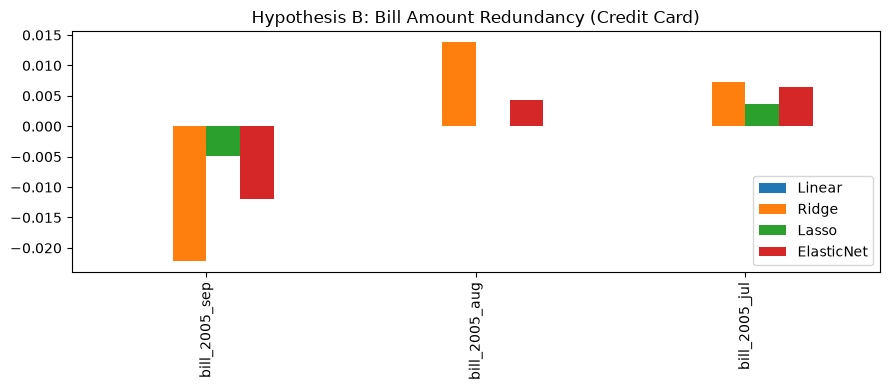

In [21]:
# Hypothesis B (credit card): does Lasso zero out bill amount columns
# from the known-redundant group (Week 1 found VIF 7.3-15.7 across
# bill_2005_sep, bill_2005_aug, bill_2005_jul), while Ridge shrinks them
# together instead, the same test as bankruptcy's Hypothesis B but with
# a more moderate degree of known redundancy (monthly balance carryover,
# not shared formula components)
X_b_credit = df_credit[['bill_2005_sep', 'bill_2005_aug', 'bill_2005_jul']].dropna()
y_b_credit = df_credit.loc[X_b_credit.index, 'default_rate']

coefs_b_credit = compare_models(X_b_credit, y_b_credit, 'Hypothesis B: Bill Amount Redundancy (Credit Card)')

In [22]:
# print out the coefficients for Hypothesis B (credit card)
print(pd.DataFrame(
coefs_b_credit, index=X_b_credit.columns))

                     Linear     Ridge     Lasso  ElasticNet
bill_2005_sep -3.046553e-07 -0.022206 -0.004837   -0.011891
bill_2005_aug  1.969855e-07  0.013810  0.000000    0.004266
bill_2005_jul  1.048754e-07  0.007272  0.003627    0.006441


In [23]:
# recheck VIF directly for these three bill amount columns, same method
# as Week 1, to confirm redundancy still holds and connect this week's
# Lasso/Ridge results back to that concrete evidence
X_vif_b_credit = sm.add_constant(X_b_credit)
vif_data_b_credit = pd.DataFrame({
    'Feature': X_vif_b_credit.columns,
    'VIF': [variance_inflation_factor(X_vif_b_credit.values, i) for i in range(X_vif_b_credit.shape[1])]
})
print(vif_data_b_credit)

         Feature        VIF
0          const   1.000000
1  bill_2005_sep  10.627682
2  bill_2005_aug  15.674197
3  bill_2005_jul   7.280326


Student markdown:

This test mirrors bankruptcy's Hypothesis B, using Week 1's confirmed bill-amount redundancy to see whether Lasso and Ridge handle it the same way. R squared was extremely low here (0.001-0.003), even lower than Hypothesis A, meaning bill amount alone barely predicts default rate, this hypothesis is about redundancy handling, not raw predictive power. Train and test gaps stayed small and slightly negative (-0.0006 to -0.0008) across all four models, so none overfit.

I tuned alpha via cross-validation: Ridge selected alpha=10.0, while Lasso and Elastic Net both selected a much gentler alpha=0.001, the same pattern as Hypothesis A and as bankruptcy, Ridge needing a stronger penalty to meaningfully shrink coefficients since it never eliminates a feature outright, only moderates it.

Rechecking VIF confirmed the same redundancy Week 1 found: bill_2005_sep at 10.63, bill_2005_aug at 15.67, and bill_2005_jul at 7.28, closely matching Week 1's reported range of 7.3-15.7. This pattern actually makes intuitive sense: bill_2005_aug, the middle month of the three, has the highest VIF because it can be predicted from *both* neighboring months at once, September and July each only have one neighbor to draw from. This is different from Hypothesis A, where both features (pay_2005_sep, pay_2005_aug) showed identical VIF (1.09 each), since with only two adjacent months and no middle position, neither feature has an extra neighbor the other lacks, the three-column setup here is what actually creates the asymmetry. That's exactly why Lasso eliminated bill_2005_aug specifically, its coefficient came out to exactly 0.000000, while bill_2005_sep and bill_2005_jul kept real, nonzero Lasso coefficients (-0.0048 and 0.0036).

As with Hypothesis A, Linear's coefficients were vanishingly small in raw scale (-3.05e-07, 1.97e-07, 1.05e-07), the same scale-distortion pattern from bill amounts being on a similarly large dollar scale as payment amount (Module B found bill amounts averaging 38,000 to 51,000 across the year). In the chart, Ridge's bars are consistently the tallest of the three regularized models, followed by Elastic Net, then Lasso, holding true across all three bill columns, the same Ridge > Elastic Net > Lasso ordering found in Hypothesis A's payment amount test, even though this hypothesis eliminated one feature entirely and Hypothesis A didn't. That consistency across both credit card hypotheses is worth comparing directly to bankruptcy: in bankruptcy, Linear's coefficient was always dramatically larger than the other three, but the relative ordering among Ridge, Lasso, and Elastic Net varied more between hypotheses, while credit card's ordering held steady in both, even with only a handful of features tested so far.

Student markdown:

Conclusion:

**Overfitting:** Same approach as bankruptcy, I used Ridge, Lasso, and Elastic Net to reduce overfitting compared to plain linear regression. Train and test R squared gaps stayed small and slightly negative for both hypotheses (-0.0032 to -0.0038 for Hypothesis A, -0.0006 to -0.0008 for Hypothesis B), so none of the four models overfit.

**Metrics and results:** R squared was low across both hypotheses (0.006-0.009 for Hypothesis A, 0.001-0.003 for Hypothesis B), so this week's credit card tests are really about how each model handles feature relationships, not raw predictive strength. Alpha was tuned via cross-validation for both hypotheses, Ridge consistently selected alpha=10.0, Lasso and Elastic Net both selected a much gentler alpha=0.001, the same pattern as bankruptcy. Across both hypotheses, coefficient bar height held a consistent order: Ridge tallest, then Elastic Net, then Lasso.

**Expected vs. unexpected:** I did not expect Linear's coefficients for either hypothesis to shrink as close to zero as they did (values around 1e-7). I already knew credit card's tested variables were outlier-heavy and large in scale, but actually seeing Linear collapse this small was still surprising, even though it makes complete sense once I worked through why: raw dollar values in the tens of thousands to millions force Linear's coefficient to be extraordinarily tiny to produce a sensible prediction.

What was expected was bill_2005_aug getting eliminated by Lasso, this connects to Week 1's finding that adjacent bill-amount months correlate above 0.9 with each other, since a customer's balance carries over month to month. Sitting in the middle of the three months, August can be predicted from both its neighbors at once, if you already have September and July's information, August adds comparatively little new information, exactly why it was the one Lasso dropped.

Also expected, though only really clear in hindsight, was that regularization behaved more consistently across credit card's two hypotheses than it did across bankruptcy's. This connects to a finding from my earlier capstone proposal's PCA work: bankruptcy's PC1 captured only 13% of variance, needing 10 components to reach even 49%, while credit card's PC1 alone captured 28%, with just two components reaching around 46%. Bankruptcy spreads its information thin across many features, so it makes sense that more of its tested variables ended up redundant and removable, 3 out of 6 features eliminated across its two hypotheses, versus credit card's 1 out of 5. Credit card's information seems to concentrate more efficiently in fewer variables, so fewer needed to be dropped.

**EDA usefulness:** Both hypotheses came directly from prior findings, Module B flagged payment and bill amounts as extreme, outlier-heavy in scale, and Week 1's VIF work already confirmed bill-amount redundancy across months. Without that groundwork, I wouldn't have known which columns were actually worth testing for this week's specific questions.

**Sources:** Same source as the bankruptcy section, GeeksforGeeks, "Lasso vs Ridge vs Elastic Net" (https://www.geeksforgeeks.org/machine-learning/lasso-vs-ridge-vs-elastic-net-ml/), since it directly explains the multicollinearity and elimination behavior demonstrated in both datasets this week.

**Bigger picture, research questions:** This connects to my first research question, which variables actually carry unique, predictive information, not just which ones correlate with the target, but which ones hold up once modeled together, and where in the data (like the middle of a time sequence) a variable is more likely to be redundant. It also connects to scale as its own important issue: without standardizing, Linear let large-scale variables collapse into near-uselessness in the raw coefficients, while regularization kept them meaningfully comparable to other variables on the same footing.

For my second research question, whether credit default is easier or harder to model than bankruptcy, this week adds a new angle beyond R squared alone: VIF values for credit card stayed comparatively modest (1.09 to 15.67) next to bankruptcy's extreme range (11.55 to over a quadrillion), and similarly-named or related columns didn't automatically produce extreme VIF the way bankruptcy's near-duplicate ratios did. Combined with fewer variables needing elimination and more consistent bar-height ordering across both hypotheses, credit card's tested features appear more stable and less redundant than bankruptcy's, even though not every column in either dataset has been tested yet.

**How I know the conclusions are true:** These are grounded in concrete numbers: R squared checked on both train and test data, cross-validated alpha values, exact coefficient magnitudes showing Linear's scale collapse, VIF values explaining exactly which feature Lasso eliminated and why, and a consistent, reproducible bar-height ordering across both hypotheses in the chart, not just a single result taken at face value.

Summary:

This week tested whether Lasso, Ridge, and Elastic Net actually behave the way this week's lesson describes, using real features from both datasets. Both bankruptcy hypotheses confirmed the theory clearly: correlated features (ROA(A)/ROA(B) at a moderate VIF of 11.55, and the leverage ratio pairs at Week 1's extreme VIF of hundreds of thousands to over a quadrillion) caused Linear Regression to produce unstable, exaggerated, often opposite-signed coefficients, while Ridge shrank all correlated features toward smaller, more stable values, and Lasso eliminated the redundant ones outright, down to essentially exact zero. Seeing this pattern hold at two very different severity levels was stronger evidence than either result alone. Across bankruptcy's two hypotheses, 3 of the 6 tested features ended up eliminated by Lasso.

Credit card confirmed the same VIF-driven elimination logic, but with a genuinely different overall pattern: only 1 of the 5 tested features (bill_2005_aug) was eliminated, and VIF values stayed comparatively modest (1.09 to 15.67) next to bankruptcy's extreme range. The coefficient ordering across models (Ridge tallest, then Elastic Net, then Lasso) also held consistently across both credit card hypotheses, while bankruptcy's ordering varied more between its two tests. This connects directly to a PCA finding from my earlier capstone proposal work: bankruptcy's first principal component captured only 13% of variance, needing 10 components to reach even 49%, while credit card's first component alone captured 28%, reaching 46% with just two. Bankruptcy spreads its information thin across many features, consistent with more of its tested variables turning out redundant and removable, while credit card's information concentrates more efficiently, consistent with fewer variables needing to be dropped and more stable, consistent behavior across tests.

The standout finding across both credit card hypotheses was the scale-distortion effect: Linear Regression's raw coefficients came out on the order of 1e-7, literally millions of times smaller than Ridge, Lasso, and Elastic Net's standardized coefficients, concrete, numeric proof that comparing coefficients across models without standardizing first would be deeply misleading, especially for features with extreme dollar-value scales like these. This same distortion did not appear in bankruptcy, since its features are naturally small, bounded financial ratios rather than raw dollar amounts.

Overall, this week reinforced that regularization does real, verifiable, quantitatively consistent work, VIF predicted exactly which features Lasso would eliminate, scale-distortion showed up with striking precision once actual coefficient values were checked, and the two datasets' differing severity of redundancy lines up with their differing PCA structure, adding a genuinely new, evidence-based angle to whether bankruptcy is harder to model than credit default.